Banknote Authentication – Clustering Algorithms(K-means)
Name:Jairus Omondi
RegNo: SCT213-C002-0079/2023

1.Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
df_no_pca = pd.read_csv("df_no_pca.csv")
df_with_pca = pd.read_csv("df_with_pca.csv")
df_no_pca.head()
df_with_pca.head()

,PC1,PC2
0,-1.674836,0.502793
1,-1.794788,0.342299
2,0.118302,1.319586
3,-2.222742,-0.624601
4,1.000248,0.512508


2.Loading and Checking Data
pd.read_csv() was used to load the two prepared datasets:
a.df_no_pca: scaled original features (no PCA applied)
b.df_with_pca: data reduced using PCA (PC1 and PC2)
head() was used to display the first 5 rows of each dataset to confirm:
a.data loaded correctly
b.structure of the datasets
c.readiness for modelling
This step ensures both datasets are properly loaded for clustering analysis.

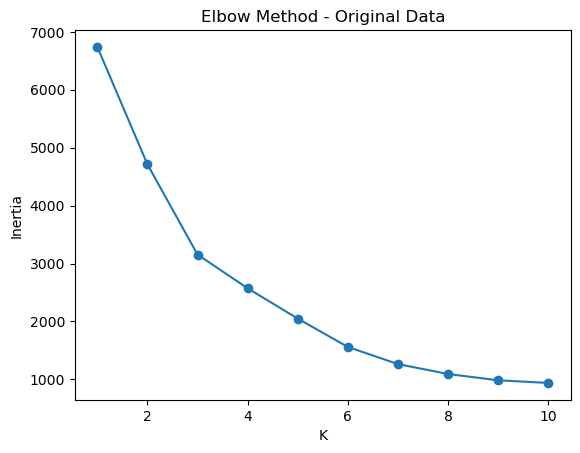

In [3]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_no_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method - Original Data")
plt.show()

3.Elbow Method (Original Data)
In this step, the Elbow Method was used to determine the optimal number of clusters (K) for K-Means.
An empty list inertia was created to store inertia values for different K values.
A loop was used to train K-Means for values of K from 1 to 10.
For each K, the model was fitted on the original dataset (df_no_pca) and the inertia value was recorded.
Inertia measures how tightly the data points are grouped within clusters (lower values indicate better compactness).
Finally:
-A line plot was generated showing K vs Inertia
-The “elbow point” on the graph helps identify the best K value, where adding more clusters gives minimal improvement.

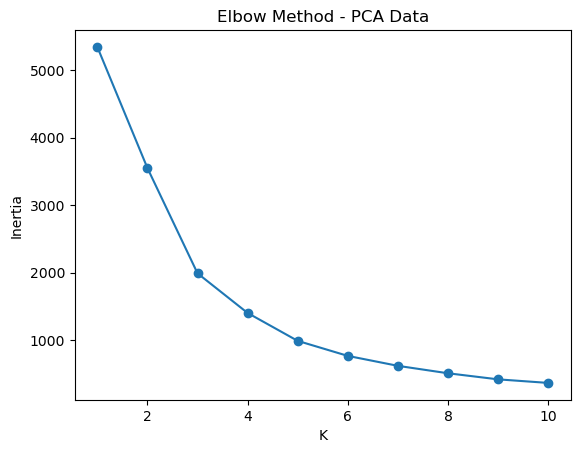

In [4]:
inertia_pca = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_with_pca)
    inertia_pca.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia_pca, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method - PCA Data")
plt.show()

4.Elbow Method (PCA Data)
In this step, the Elbow Method was applied to the PCA-transformed dataset to determine the optimal number of clusters (K).
An empty list inertia_pca was created to store inertia values for different K values.
A loop was used to train K-Means models for K values from 1 to 10.
For each K, the model was fitted on the PCA dataset (df_with_pca) and the inertia value was recorded.
Inertia measures how closely data points are grouped within clusters, with lower values indicating better compactness.
Finally:
A plot of K vs Inertia was generated.
The elbow point helps identify the most suitable number of clusters for the PCA-reduced data.

In [5]:
kmeans_orig = KMeans(n_clusters=2, random_state=42)
labels_orig = kmeans_orig.fit_predict(df_no_pca)

df_no_pca["Cluster"] = labels_orig
print("First rows (Original):")
print(df_no_pca.head())

print("\nCluster distribution (Original):")
print(df_no_pca["Cluster"].value_counts())

First rows (Original):
   variance  skewness  curtosis   entropy  outlier_flag  Cluster
0  1.109709  1.151820 -0.975529  0.346132     -0.269062        0
1  1.432683  1.066810 -0.894937 -0.140707     -0.269062        0
2  1.195109 -0.775147  0.118015  0.611558     -0.269062        0
3  1.052054  1.297854 -1.253774 -1.163342     -0.269062        0
4 -0.040724 -1.084859  0.729928  0.086284     -0.269062        0

Cluster distribution (Original):
Cluster
0    1257
1      91
Name: count, dtype: int64


5.K-Means Clustering on Original Data
In this step, K-Means clustering was applied to the original scaled dataset.
A K-Means model was created with K = 2 clusters and a fixed random_state for reproducibility.
The model was fitted on df_no_pca, and cluster labels were generated using fit_predict().
These labels were added to the dataset as a new column called Cluster.
Finally:
The first few rows of the dataset were displayed to verify that cluster labels were added correctly.
The distribution of data points across clusters was printed to show how the data was grouped.

In [6]:
kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca = kmeans_pca.fit_predict(df_with_pca)

df_with_pca["Cluster"] = labels_pca
print("\nFirst rows (PCA):")
print(df_with_pca.head())

print("\nCluster distribution (PCA):")
print(df_with_pca["Cluster"].value_counts())


First rows (PCA):
        PC1       PC2  Cluster
0 -1.674836  0.502793        0
1 -1.794788  0.342299        0
2  0.118302  1.319586        0
3 -2.222742 -0.624601        0
4  1.000248  0.512508        0

Cluster distribution (PCA):
Cluster
0    1257
1      91
Name: count, dtype: int64


6.K-Means Clustering on PCA Data
In this step, K-Means clustering was applied to the PCA-transformed dataset.
A K-Means model was created with K = 2 clusters and a fixed random_state for consistency.
The model was fitted on the PCA dataset (df_with_pca), and cluster labels were generated using fit_predict().
These labels were added as a new column called Cluster.
Finally:
The first few rows were displayed to confirm that cluster labels were successfully added.
The distribution of data points in each cluster was printed to show how the PCA data was grouped.

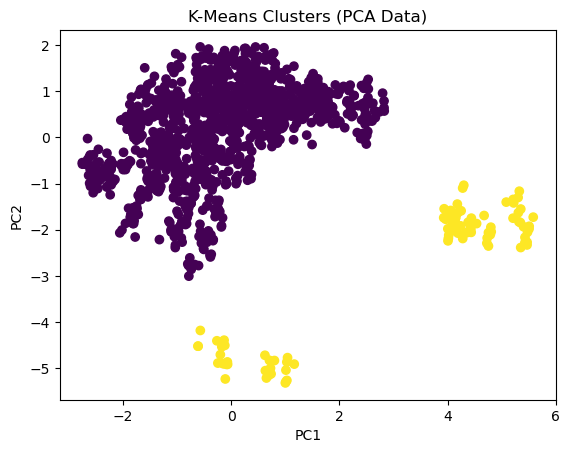

In [7]:
plt.scatter(df_with_pca["PC1"], df_with_pca["PC2"], c=df_with_pca["Cluster"])
plt.title("K-Means Clusters (PCA Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Cluster Visualization (PCA Data)
In this step, a scatter plot was created to visualize the clustering results on the PCA-transformed dataset.
The two principal components (PC1 and PC2) were used as the x and y axes.
Each data point was colored based on its assigned Cluster from the K-Means model.
This visualization helps to clearly see how well the data points are separated into different groups in reduced 2D space.
Finally, the plot was displayed to show the cluster structure visually.

PCA Cluster Plot Interpretation
The plot shows K-Means clustering results on PCA data (PC1 vs PC2).
Each point represents a data sample, colored by its assigned cluster.
Two clear clusters are visible, showing good separation of the data.
This means PCA helped simplify the data while still keeping useful structure for clustering.

In [8]:
print("Silhouette (Original):",
      silhouette_score(df_no_pca.drop("Cluster", axis=1), labels_orig))

print("Silhouette (PCA):",
      silhouette_score(df_with_pca.drop("Cluster", axis=1), labels_pca))

Silhouette (Original): 0.5873041175780581
Silhouette (PCA): 0.6283771249415785


8.The code evaluates the performance of a K-Means clustering model using the Silhouette Score in two scenarios:
Original data: Clustering done on the full feature set
PCA data: Clustering done after reducing dimensions using PCA
The silhouette_score() function measures how well each data point fits within its assigned cluster compared to other clusters.
Output meaning
Silhouette (Original): 0.587 → Good clustering, but some overlap between clusters
Silhouette (PCA): 0.628 → Better clustering after PCA, meaning clearer and more separated clusters
Final takeaway
PCA improved the clustering quality, so your K-Means model performs better on reduced-dimensional data compared to the original dataset.

In [9]:
print("DB Index (Original):",
      davies_bouldin_score(df_no_pca.drop("Cluster", axis=1), labels_orig))

print("DB Index (PCA):",
      davies_bouldin_score(df_with_pca.drop("Cluster", axis=1), labels_pca))

DB Index (Original): 0.8685819661898775
DB Index (PCA): 0.8317197318556788


9.The code evaluates your K-Means clustering quality using the Davies–Bouldin Index (DBI) for two cases:
Original data (no PCA)
PCA-transformed data
It compares how good the clusters are based on:
How compact each cluster is
How far apart different clusters are
Lower values = better clustering.
Output meaning
DB Index (Original): 0.8686 → Decent clustering, but clusters are slightly less well separated
DB Index (PCA): 0.8317 → Better clustering after PCA, more compact and more separated clusters
Final takeaway
PCA improved your clustering quality again because:
It reduced noise and redundancy
Made clusters more distinct
Since lower DB Index is better, PCA data gives the better K-Means performance compared to the original dataset.

In [10]:
print("CH Score (Original):",
      calinski_harabasz_score(df_no_pca.drop("Cluster", axis=1), labels_orig))

print("CH Score (PCA):",
      calinski_harabasz_score(df_with_pca.drop("Cluster", axis=1), labels_pca))

CH Score (Original): 579.0705647815096
CH Score (PCA): 680.7154621493605


10.This code evaluates your K-Means clustering performance using the Calinski-Harabasz (CH) Score for:
Original dataset (no PCA)
PCA-reduced dataset
The CH Score measures:
How well-separated clusters are
How compact each cluster is
Higher values = better clustering

Output meaning
CH Score (Original): 579.07 → Good clustering quality
CH Score (PCA): 680.72 → Better clustering after PCA

Final takeaway
PCA improved clustering performance again because:
It increased cluster separation
Reduced noise in the data
Made group structure clearer
Since CH Score is higher after PCA, my PCA-based K-Means model is the best performing version overall across all metrics.

In [11]:
print(df_no_pca["Cluster"].value_counts())
print(df_with_pca["Cluster"].value_counts())

Cluster
0    1257
1      91
Name: count, dtype: int64
Cluster
0    1257
1      91
Name: count, dtype: int64


11.The code checks how many data points are assigned to each cluster in both models:
It simply counts the number of samples in each cluster after K-Means clustering.

Output meaning
Both results are identical:
Cluster 0 → 1257 points
Cluster 1 → 91 points

Interpretation
The dataset is highly imbalanced in cluster distribution
Most data points belong to Cluster 0
A small group belongs to Cluster 1, which may represent rare or unusual patterns (possible anomalies or a minority class structure)

Final takeaway
PCA did not change cluster assignments significantly in terms of distribution
Both models produced the same clustering split
However, earlier metrics show PCA improved cluster quality (better separation and structure), even though the cluster sizes stayed the same

